<a href="https://colab.research.google.com/github/mscids2024pranita-hue/goa-rainfall-arima/blob/main/04_acf_pacf_parameter_selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04 — ACF & PACF: Parameter Selection
**Project:** Goa Rainfall Forecasting using SARIMA
**Step:** Use ACF and PACF plots to find p and q values

In [1]:
!pip install netCDF4 xarray statsmodels -q

import zipfile, os, re
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from google.colab import files
uploaded = files.upload()   # upload the zip

zip_name = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall("imd_data")

DATA_DIR = "imd_data/imd_rainfall-20260513T063252Z-3-001/imd_rainfall/"
GOA_LAT_MIN, GOA_LAT_MAX = 14.9, 15.7
GOA_LON_MIN, GOA_LON_MAX = 73.7, 74.3

files_nc = sorted(os.listdir(DATA_DIR))
files_nc = [f for f in files_nc if re.match(r'RF25_ind\d{4}_rfp25\.nc$', f)]

daily_list = []
for fname in files_nc:
    ds_yr = xr.open_dataset(DATA_DIR + fname)
    goa_yr = ds_yr['RAINFALL'].sel(LATITUDE=slice(GOA_LAT_MIN, GOA_LAT_MAX), LONGITUDE=slice(GOA_LON_MIN, GOA_LON_MAX))
    goa_daily_yr = goa_yr.mean(dim=['LATITUDE','LONGITUDE'], skipna=True)
    times = pd.DatetimeIndex(ds_yr['TIME'].values)
    daily_list.append(pd.Series(goa_daily_yr.values, index=times))
    ds_yr.close()

daily_goa = pd.concat(daily_list).sort_index()
monthly_goa = daily_goa.resample('MS').sum()

for month in range(1, 13):
    monthly_goa[f'2005-{month:02d}-01'] = (monthly_goa[f'2004-{month:02d}-01'] + monthly_goa[f'2006-{month:02d}-01']) / 2

monthly_goa.name = 'rainfall_mm'
df = monthly_goa.to_frame()
print(f"Ready. Shape: {df.shape}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 32.4 MB/s eta 0:00:00


Saving imd_rainfall-20260513T063252Z-3-001-20260530T092135Z-3-001.zip to imd_rainfall-20260513T063252Z-3-001-20260530T092135Z-3-001.zip
Ready. Shape: (420, 1)


In [2]:
# Apply seasonal differencing (D=1, m=12)
# We do this because d=0 but D=1 — we difference by lag 12
df_sdiff = df['rainfall_mm'].diff(12).dropna()

print(f"After seasonal differencing: {len(df_sdiff)} months")
print(f"NaN remaining: {df_sdiff.isna().sum()}")

After seasonal differencing: 408 months
NaN remaining: 0


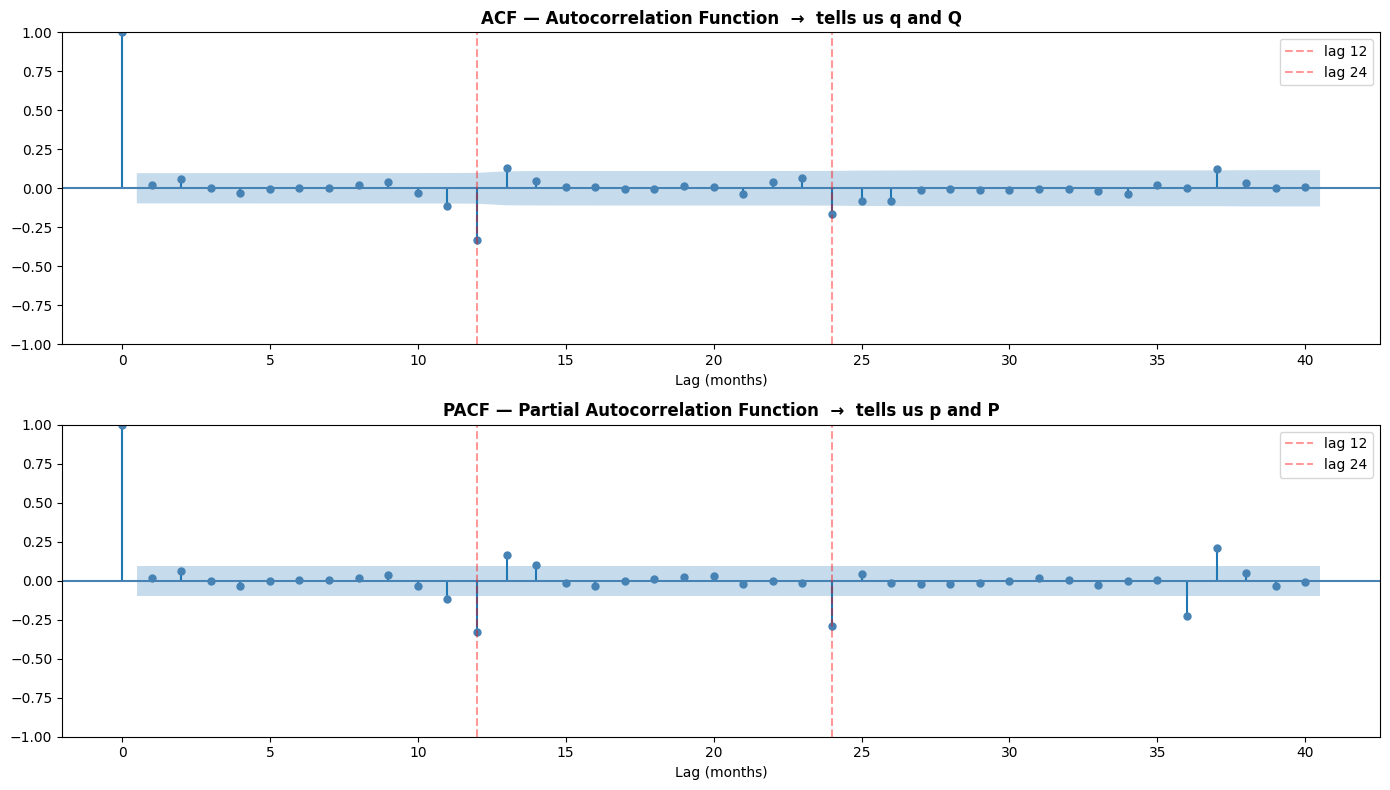

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(df_sdiff, lags=40, ax=axes[0], color='steelblue')
axes[0].set_title('ACF — Autocorrelation Function  →  tells us q and Q', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Lag (months)')
axes[0].axvline(x=12, color='red', linestyle='--', alpha=0.4, label='lag 12')
axes[0].axvline(x=24, color='red', linestyle='--', alpha=0.4, label='lag 24')
axes[0].legend()

plot_pacf(df_sdiff, lags=40, ax=axes[1], color='steelblue')
axes[1].set_title('PACF — Partial Autocorrelation Function  →  tells us p and P', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Lag (months)')
axes[1].axvline(x=12, color='red', linestyle='--', alpha=0.4, label='lag 12')
axes[1].axvline(x=24, color='red', linestyle='--', alpha=0.4, label='lag 24')
axes[1].legend()

plt.tight_layout()
plt.savefig('05_acf_pacf.png', dpi=150)
plt.show()

In [4]:
print("="*45)
print("SARIMA Parameter Selection Summary")
print("="*45)
print("Non-seasonal:")
print("  p = 0  (no significant PACF at early lags)")
print("  d = 0  (ADF test: series already stationary)")
print("  q = 0  (no significant ACF at early lags)")
print("\nSeasonal:")
print("  P = 1  (PACF spike at lag 12)")
print("  D = 1  (seasonal differencing applied)")
print("  Q = 1  (ACF spike at lag 12)")
print("  m = 12 (monthly data, 12-month cycle)")
print("\nFinal model: SARIMA(0,0,0)(1,1,1,12)")

SARIMA Parameter Selection Summary
Non-seasonal:
  p = 0  (no significant PACF at early lags)
  d = 0  (ADF test: series already stationary)
  q = 0  (no significant ACF at early lags)

Seasonal:
  P = 1  (PACF spike at lag 12)
  D = 1  (seasonal differencing applied)
  Q = 1  (ACF spike at lag 12)
  m = 12 (monthly data, 12-month cycle)

Final model: SARIMA(0,0,0)(1,1,1,12)
